In [1]:
from datasets import load_dataset
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import polars as pl
import io
from PIL import Image
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
ds = load_dataset("dragonintelligence/CIFAKE-image-dataset")

## Fake 0, Real 1

In [3]:
df_train=ds['train'].to_polars()
df_test=ds['test'].to_polars()

# Exploration Data Analysis

In [4]:
data=df_train

In [5]:
data.shape

(100000, 2)

In [6]:
data.null_count()

image,label
u32,u32
0,0


In [7]:
data['image'][0]

{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x00 \x00 \x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\

The image exist in a raw form we need to convert it into a readable format

In [8]:
data.columns

['image', 'label']

### Visualize the distribution of the data labels

### In order to be able to explore and visualize the given data, we need to preprocess it first

In [9]:
schema=pl.Struct([
    pl.Field("Mode",     pl.String),
    pl.Field("Width",    pl.Int32),
    pl.Field("Height",   pl.Int32),
    pl.Field("Mean_RGB", pl.Float64),
    pl.Field("Mean_R",   pl.Float64),
    pl.Field("Mean_G",   pl.Float64),
    pl.Field("Mean_B",   pl.Float64),
    pl.Field("nbytes",   pl.Int64)
])

In [10]:
def image_details(img_bytes):
    img=Image.open(io.BytesIO(img_bytes))
    pixels=np.array(img.convert('RGB'), dtype=np.float32)
    meta_data={
        "Mode": img.mode,
        "Width": img.width,
        "Height": img.height,
        "Mean_RGB": pixels.mean(),
        "Mean_R":pixels[:,:,0].mean(),
        "Mean_G":pixels[:,:,1].mean(),
        "Mean_B":pixels[:,:,2].mean(),
        "nbytes":len(img_bytes)
    }
    return meta_data

In [11]:
def preprocess_images(d):
    # preprocess the image and extract the path and the byte
    d=d.unnest('image')
    # Obtain meta data for the images
    d=d.with_columns(
        pl.col('bytes').map_elements(image_details, return_dtype=schema).alias("images_metadata"))
    # separate the columns 
    d=d.unnest('images_metadata')

    # drop unnecessary columns
    d=d.drop(['path'])
    
    return d

In [12]:
data=preprocess_images(data)

#### The distribution of the class labels

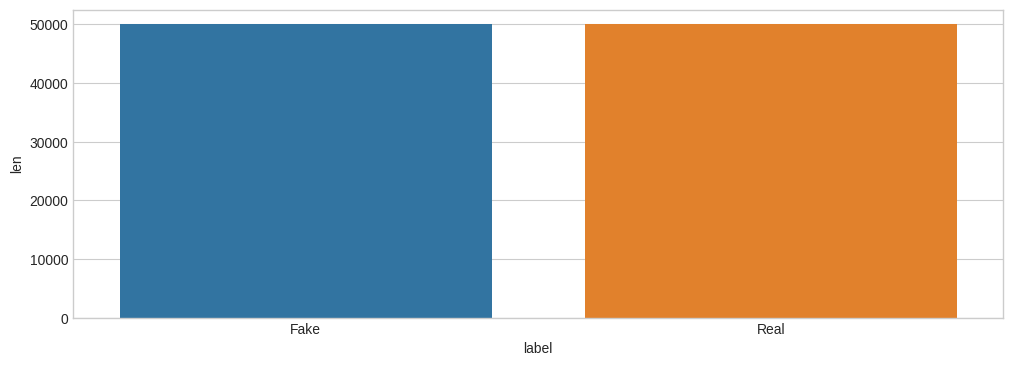

In [13]:
plt.figure(figsize=(12, 4))
labels_df=data.group_by("label").agg(pl.len(), pl.col('Mean_RGB').sum()).with_columns(
    pl.when(pl.col('label')==0).then(pl.lit('Fake')).otherwise(pl.lit('Real')).alias('label')
)
plot=sns.barplot(labels_df, x='label', y='len', hue='label')
plt.show()

#### Distribution of the of each color distribution based on the class laebl

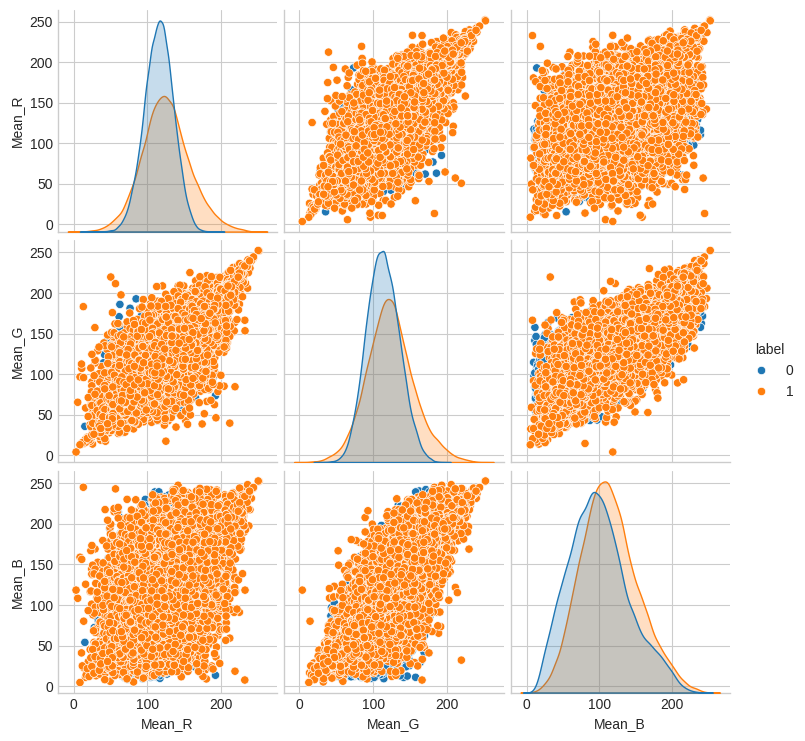

In [16]:
means_rgb=data.select("Mean_R", "Mean_G","Mean_B", "label").to_pandas()
sns.pairplot(data=means_rgb, hue='label')
plt.show()

### Displaying Some images with their classes

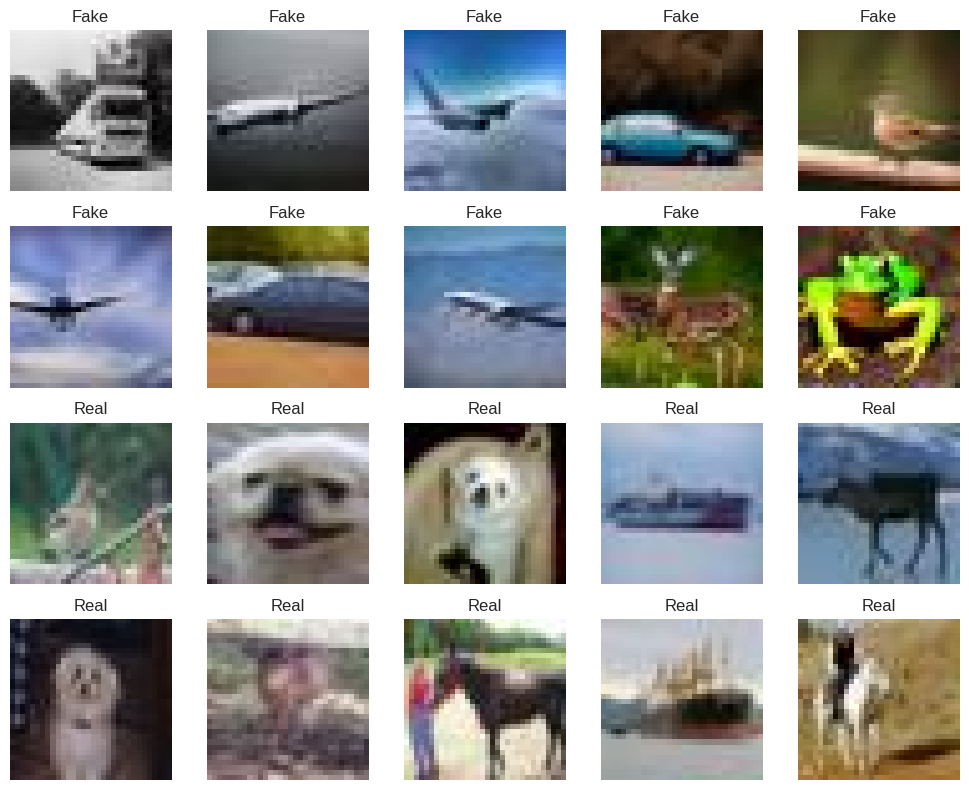

In [41]:
def plot_images(d, num, size=(10,8), plots=(4,5)):
    # num represent the sample for each label in the class
    d=d.filter(pl.int_range(pl.len()).shuffle().over('label') <10)
    fig, axes=plt.subplots(plots[0], plots[1], figsize=size)
    axes=axes.flatten()
    images=d['bytes']
    labels=d['label']

    for i, (img, label) in enumerate(zip(images, labels)):
        ax=axes[i]
        img=Image.open(io.BytesIO(img))
        ax.imshow(img)
        label='Fake' if label==0 else 'Real'
        ax.axis('off')
        ax.set_title(label)
    plt.tight_layout()
    plt.show()
        
plot_images(data, 10)

### Display discriptive Statistics

In [ ]:
statistics=data.to_pandas()

# Modelling and Data Preprocessing

### converting the images into pytorch suitable format --requires more memory

In [4]:
transform=v2.Compose([
      v2.RandomHorizontalFlip(p=0.4),
      v2.ToDtype(torch.float32, scale=True),
      v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
##TODO prepare the dataset and put all transformations there

### Prepare the class and the data loaders to start modelling

In [6]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
# specify a method to convert the images into a tensor
# available once: 1. through numpy, 2. through torchvision
class dataset(Dataset):
    
    def __init__(self, data, transform=None):
        super(dataset, self).__init__()
        self.polars_data=data
        self.transform=transform
        self.pil_images=None
        self.tensor=None
        self.tensor_np=None
        self.classes=None
        self.convert_images_into_bytes()
            
    def __len__(self):
        if self.tensor!=None:
            return self.tensor.shape[0]
        return None
            
    def __getitem__(self, index):
        if self.tensor!=None:
            return self.tensor[0]
        return None        
    def convert_images_into_bytes(self):
        self.polars_data=self.polars_data.with_columns(
            pl.col('image').struct.field('path').alias("image_path"),
            pl.col('image').struct.field('bytes').alias('image_bytes')
        )
        self.pil_images=[Image.open(io.BytesIO(img)) for img in self.polars_data['image_bytes'].to_list()]
    
        return self

    def transform_to_tensor(self): # d: a list of the PIL images
        images=[v2.functional.to_image(img) for img in self.pil_images]
        images=torch.stack(images)
        self.tensor=self.transform(images)
        return self

    def transform_to_tensor_through_numpy(self):
        array=np.array(self.pil_images)
        self.tensor_np=torch.from_numpy(array)    
        return self

    def fill_classes(self):
        self.classes= self.polars_data.select(pl.col('label')).to_torch()
        return self

    def prepare(self):
        self.transform_to_tensor()
        self.fill_classes()
        return self.tensor, self.classes

    def loading(self):
        image, label=self.prepare()
        return train_test_split(image, label, random_state=42, test_size=0.3)

In [7]:
class EarlyStopping():
    def __init__(self, delta=0.02, patience=5):
        self.delta=delta
        self.patience=patience
        self.best_val=None
        self.stop_training=False
        self.steps=0

    def early_stopping_val(self, val_loss):
        if self.best_val is None or val_loss < self.best_val - self.delta:
            self.best_val=val_loss
            self.steps=0
        else:
            if self.patience==self.steps:
                self.stop_training=True
                print("Early Stop Training is Applied-- The Training halts")
            else:
                self.steps+=1

In [8]:
train_obj=dataset(df_train, transform)
test_obj=dataset(df_test, transform)

In [9]:
df_train, df_eval, class_train, class_eval=train_obj.loading()

### Custom CNN Model

In [10]:
# class MaintainGradients(nn.Module):
#     def __init__(self, ch, kernel, device, dropout):
#         super(MaintainGradients, self).__init__()
        
#         self.relu=nn.ReLU(inplace=False)
        
#         self.features=nn.Sequential(
#             nn.Dropout(dropout),
#             nn.Conv2d(ch, ch, kernel_size=kernel, padding=1, stride=1, device=device),
#             nn.BatchNorm2d(ch, device=device),
#             nn.ReLU(inplace=False),
#             nn.Conv2d(ch, ch, kernel_size=kernel, padding=1, stride=1, device=device),
#             nn.BatchNorm2d(ch, device=device)
#         )
#     def forward(self, x):
#         # the idea is to keep x and apply addition to the resulted value of network
#         data=x
#         output=self.features(x)
#         output+=data
#         return self.relu(output)

In [11]:
class ConvNN(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, device, dropout, num_classes=2):
        super(ConvNN, self).__init__()
        self.modelling=nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel +4, padding=6, stride=1, device=device),
            nn.BatchNorm2d(out_ch, device=device),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(out_ch, out_ch * 2, kernel_size=kernel+2, padding=4, stride=1, device=device),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(out_ch * 2, out_ch * 3, kernel_size=kernel, padding=2, stride=1, device=device),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(out_ch * 3, out_ch * 2, kernel_size=kernel+2, padding=4, stride=1, device=device),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(out_ch * 2, out_ch, kernel_size=kernel, padding=2, stride=1, device=device),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

        )
        
        self.features=nn.Sequential(
            nn.Dropout(dropout), 
            nn.Conv2d(out_ch, out_ch //2, kernel_size=kernel, padding=1, device=device),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier=nn.Sequential(
            nn.Dropout(dropout), 
            nn.Linear(out_ch //2, out_ch, device=device),
            nn.ReLU(inplace=True),
            nn.Linear(out_ch, num_classes, device=device),
        )

    def forward(self, x):
        x=self.modelling(x)
        output=self.features(x)
        output=output.squeeze(2, 3)
        output=self.classifier(output)
        return output

### Multi-Layer Perceptron Model

In [12]:
class MLP(nn.Module):
    def __init__(self, in_ch, out_ch, device, dropout, num_classes=2):
        super(MLP, self).__init__()
        self.dropout=dropout
        self.flatten_layer=nn.Flatten(start_dim=1, end_dim=-1)
        self.Dense_network=nn.Sequential(
            nn.Linear(in_ch, out_ch, device=device),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(out_ch, out_ch * 2, device=device),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(out_ch * 2, out_ch * 3, device=device),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(out_ch * 3, out_ch * 2, device=device),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
        )
        self.output=nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(out_ch *2, out_ch, device=device),
            nn.ReLU(inplace=True),
            nn.Linear(out_ch, num_classes, device=device)
        )

    def forward(self, x):
        x=self.flatten_layer(x)
        x=self.Dense_network(x)
        
        return self.output(x)

In [13]:
import matplotlib.pyplot as plt

def plotting(ax, x1, x2, y, x_axis, y_axis, title):
    ax.plot(y, x1, label=x_axis)
    ax.plot(y, x2, label=y_axis)
    ax.set_title(title)
    ax.legend()

In [14]:
from torch.utils.data import DataLoader
def data_loading(data, batch_size):
    return DataLoader(data, batch_size=batch_size, shuffle=False, num_workers=1)

In [15]:
# train one epoch

def train_one_epoch(image_loader, class_loader, model, device, opt):
    train_loss, correct, total=0,0,0
    criterion=nn.CrossEntropyLoss()
    model.train()
    for images, label in zip(image_loader, class_loader):
        images, label=images.to(device, non_blocking=True), label.to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        label=label.squeeze(1)
        output=model(images)
        loss=criterion(output, label)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        train_loss+=loss.item() * label.size(0)
        preds=output.argmax(dim=1)
        correct+=(preds == label).sum().item()
        total+=label.size(0)
        torch.cuda.empty_cache()
        
    return train_loss / total, correct / total

In [16]:
# evaluate one epoch

def evaluate_one_epoch(image_loader, class_loader, model, device):
    eval_loss, correct, total=0,0,0
    criterion=nn.CrossEntropyLoss()
    model.eval()
    with torch.no_grad():
        for images, label in zip(image_loader, class_loader):
            images, label= images.to(device, non_blocking=True), label.to(device, non_blocking=True)
            label=label.squeeze()
            output=model(images)
            loss=criterion(output, label)
            eval_loss+=loss.item() * label.size(0)
            preds=output.argmax(dim=1)
            correct+=(preds==label).sum().item()
            total+=label.size(0)
            
    return eval_loss/total, correct/total

In [17]:
def train(model, num_epoch,batch_size, lr, weight_decay, tune=False, opt=None, trial=None):
    
    train_loader, train_class=data_loading(df_train, batch_size), data_loading(class_train, batch_size)
    eval_loader, eval_class=data_loading(df_eval, batch_size), data_loading(class_eval, batch_size)
    opt=opt if tune else optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    early_stopping=EarlyStopping()
    TrainLoss=[]
    EvalLoss=[]
    TrainAc=[]
    EvalAc=[]
    epochs=[]
    fig, ax=plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
    for i in range(1,num_epoch + 1):
        # load the trainer and evaluator
        train_loss, train_ac=train_one_epoch(train_loader, train_class, model, device, opt)
        eval_loss, eval_ac=evaluate_one_epoch(eval_loader, eval_class, model, device)
        # check if tuning mode is enabled 
        if not tune: # if not record the current loss and accuracy
            print(f"Epoch: {i}, Train Loss is: {train_loss:.2f}, Train Accuracy is: {train_ac:.2f}, Validation Loss:{eval_loss:.2f}, validation accuracy is: {eval_ac:.2f}")
        early_stopping.early_stopping_val(eval_loss) # early stop the training if the loss validation stopped training
        
        if tune: # if tunning mode is enabled report the loss with the epoch number
            trial.report(eval_loss, i)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
                
        if early_stopping.stop_training:
            break
            
        else:
            epochs.append(i)
            TrainLoss.append(train_loss)
            EvalLoss.append(eval_loss)
            TrainAc.append(train_ac)
            EvalAc.append(eval_ac)

    if tune:
        return eval_loss
    else:
        plotting(ax[0], TrainLoss, EvalLoss, epochs, "Training Loss", "Eval Loss", "Training And Validation Loss")
        plotting(ax[1], TrainAc, EvalAc, epochs,"Training Accuracy", "Eval Accurcy", "Training And Validation Accuracy")

In [18]:
def construct_model(in_ch, out_ch, kernel, device, dropout, name):
    if name=="CNN":
        return ConvNN(in_ch, out_ch, kernel, device, dropout)
    elif name=="MLP":
        return MLP(in_ch, out_ch, device, dropout)
    else:
        return "Not found"

In [19]:
def define_parameters(in_ch,out_ch, dropout, kernel=3):
    in_ch=in_ch
    out_ch=out_ch
    device="cuda" if torch.cuda.is_available() else "cpu"
    dropout=dropout
    kernel=kernel
    return in_ch, out_ch, device, dropout, kernel

### Preparing the CNN training params

In [20]:
in_ch=df_train.shape[1]
in_ch, out_ch, device, dropout, kernel=define_parameters(in_ch, 64, 0.4, kernel=3)
model=construct_model(in_ch, out_ch, kernel, device, dropout, "CNN")
# model=construct_model(in_ch, out_ch, kernel, device, dropout, "MLP")

### Preparing the MLP training params

In [44]:
in_ch=torch.flatten(df_train, start_dim=1, end_dim=-1).shape[1]
in_ch, out_ch, device, dropout, kernel=define_parameters(in_ch, 512, 0.4, kernel=3)
# model=construct_model(in_ch, out_ch, kernel, device, dropout, "CNN")
model=construct_model(in_ch, out_ch, kernel, device, dropout, "MLP")

### Total number of parameters

In [21]:
def get_param_count(model):
    return sum(param.numel() for param in model.parameters())

In [22]:
get_param_count(model)

1144930

Epoch: 1, Train Loss is: 0.60, Train Accuracy is: 0.64, Validation Loss:0.45, validation accuracy is: 0.78
Epoch: 2, Train Loss is: 0.41, Train Accuracy is: 0.81, Validation Loss:0.51, validation accuracy is: 0.78
Epoch: 3, Train Loss is: 0.31, Train Accuracy is: 0.87, Validation Loss:0.23, validation accuracy is: 0.91
Epoch: 4, Train Loss is: 0.23, Train Accuracy is: 0.91, Validation Loss:0.20, validation accuracy is: 0.92
Epoch: 5, Train Loss is: 0.22, Train Accuracy is: 0.91, Validation Loss:0.19, validation accuracy is: 0.93
Epoch: 6, Train Loss is: 0.19, Train Accuracy is: 0.93, Validation Loss:0.18, validation accuracy is: 0.93
Epoch: 7, Train Loss is: 0.16, Train Accuracy is: 0.94, Validation Loss:0.16, validation accuracy is: 0.94
Epoch: 8, Train Loss is: 0.15, Train Accuracy is: 0.94, Validation Loss:0.15, validation accuracy is: 0.94
Epoch: 9, Train Loss is: 0.15, Train Accuracy is: 0.94, Validation Loss:0.28, validation accuracy is: 0.88
Epoch: 10, Train Loss is: 0.15, Train

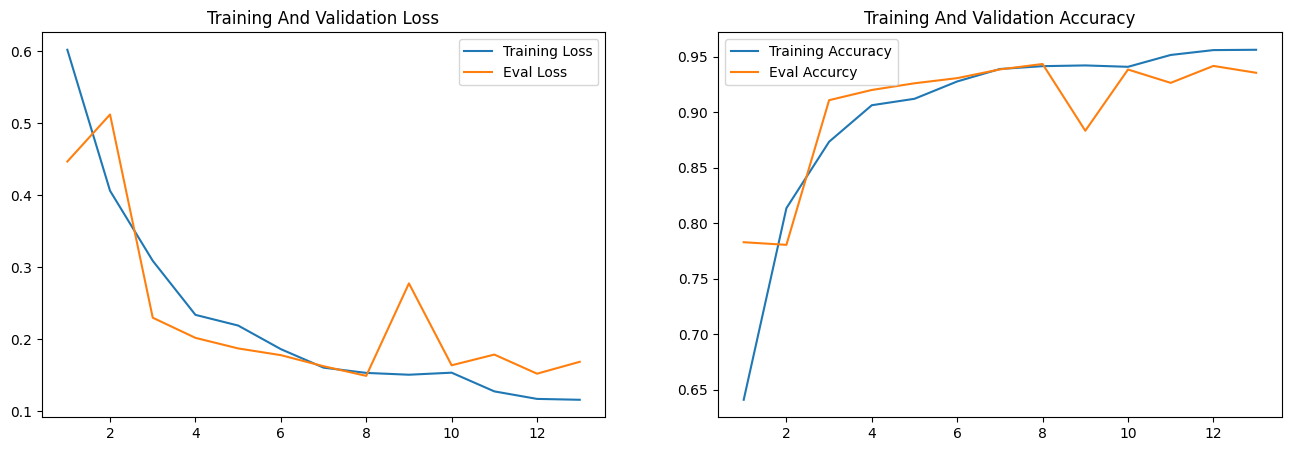

In [23]:
train(model, 30, 1000, 0.001, 0.003)

### Hyper-Parameter Tuning

In [23]:
def print_tun_stat(study):
    print('----------------------------------')
    best_trial=study.best_trial
    best_params=study.best_params
    best_value=study.best_value
    print(f"best trial: {best_trial}")
    print(f"Best Loss Value: {best_value}")

    for key, value in best_params.items():
        print(f"{key}: {value}")

### MLP Model

In [ ]:
import optuna

def objective_mlp(trial):
    # define the hyper-parameters
    lr=trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay=trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)
    dropout=trial.suggest_float("dropout", 0.2, 0.7)
    opt_name=trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    hidden_dim=trial.suggest_int("hidden_size", 64, 512)
    
    # define models' parameteres
    in_ch=torch.flatten(df_train, start_dim=1, end_dim=-1).shape[1]
    in_ch, out_ch, device, dropout, kernel=define_parameters(in_ch, hidden_dim, dropout, kernel=3)
    model=construct_model(in_ch, out_ch, kernel, device, dropout, "MLP")

    # define the optimizer
    optimizer=optim.AdamW(
        model.parameters(),lr=lr,
        weight_decay=weight_decay) if opt_name == "Adam" else optim.SGD(
        model.parameters(),lr=lr,
        weight_decay=weight_decay
    )
    # specify the number of epochs
    # early stopping is applied
    num_epochs=30
    acc=train(model, num_epochs, batch_size=2000, lr=0, weight_decay=0, tune=True, optim=optimizer, trial=trial)

    return acc

study=optuna.create_study(direction="minimize")
study.optimize(objective_mlp, n_trials=100)
print_tun_stat(study)
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)

### CNN Model

[I 2026-06-01 13:44:45,286] A new study created in memory with name: no-name-0f51d7f5-be2a-484e-8bc9-1bb7a5f5ce76
[I 2026-06-01 13:49:11,453] Trial 0 finished with value: 0.1557435929775238 and parameters: {'lr': 0.00039453344486758344, 'weight_decay': 0.002346883675019123, 'dropout': 0.35205840886074946, 'optimizer': 'Adam', 'hidden_size': 43}. Best is trial 0 with value: 0.1557435929775238.


Early Stop Training is Applied-- The Training halts


[I 2026-06-01 13:53:30,531] Trial 1 finished with value: 0.22418449595570564 and parameters: {'lr': 5.0218882952168905e-05, 'weight_decay': 0.0009952659283410672, 'dropout': 0.4711365773665041, 'optimizer': 'Adam', 'hidden_size': 31}. Best is trial 0 with value: 0.1557435929775238.


Early Stop Training is Applied-- The Training halts


[I 2026-06-01 13:56:49,241] Trial 2 finished with value: 0.2058830405275027 and parameters: {'lr': 0.0010159758687509994, 'weight_decay': 0.002261033254836243, 'dropout': 0.5785304818067241, 'optimizer': 'Adam', 'hidden_size': 22}. Best is trial 0 with value: 0.1557435929775238.


Early Stop Training is Applied-- The Training halts
----------------------------------
best trial: FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.1557435929775238], datetime_start=datetime.datetime(2026, 6, 1, 13, 44, 45, 288175), datetime_complete=datetime.datetime(2026, 6, 1, 13, 49, 11, 453395), params={'lr': 0.00039453344486758344, 'weight_decay': 0.002346883675019123, 'dropout': 0.35205840886074946, 'optimizer': 'Adam', 'hidden_size': 43}, user_attrs={}, system_attrs={}, intermediate_values={1: 0.3496094435453415, 2: 0.2609939818580945, 3: 0.20278121108810107, 4: 0.3205538789431254, 5: 0.19337217931946118, 6: 0.27013321916262306, 7: 0.16067309491336346, 8: 0.16650705511371294, 9: 0.14942339348296324, 10: 0.14823512273530165, 11: 0.1503395573546489, 12: 0.14227724137405554, 13: 0.1557435929775238}, distributions={'lr': FloatDistribution(high=0.01, log=True, low=1e-05, step=None), 'weight_decay': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'dropou

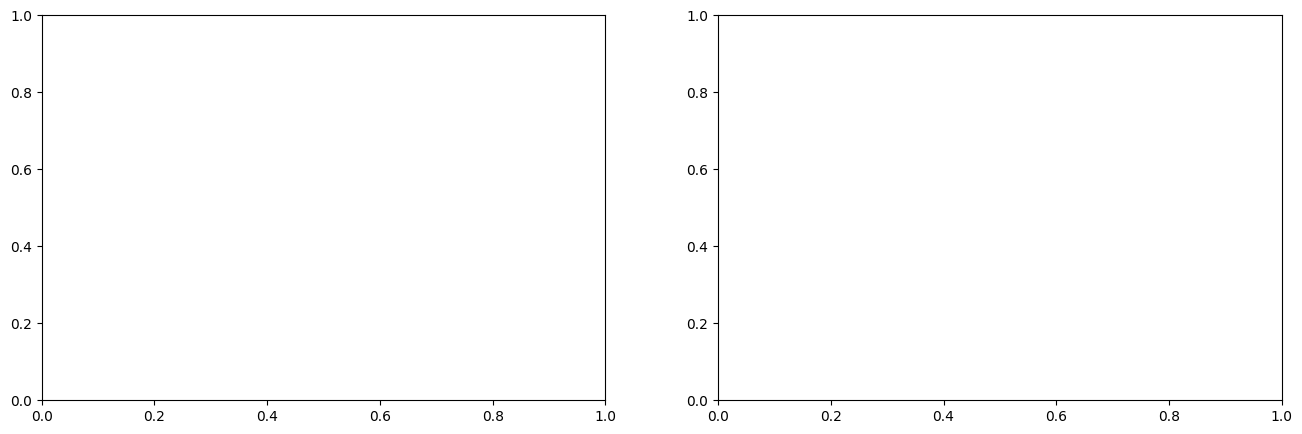

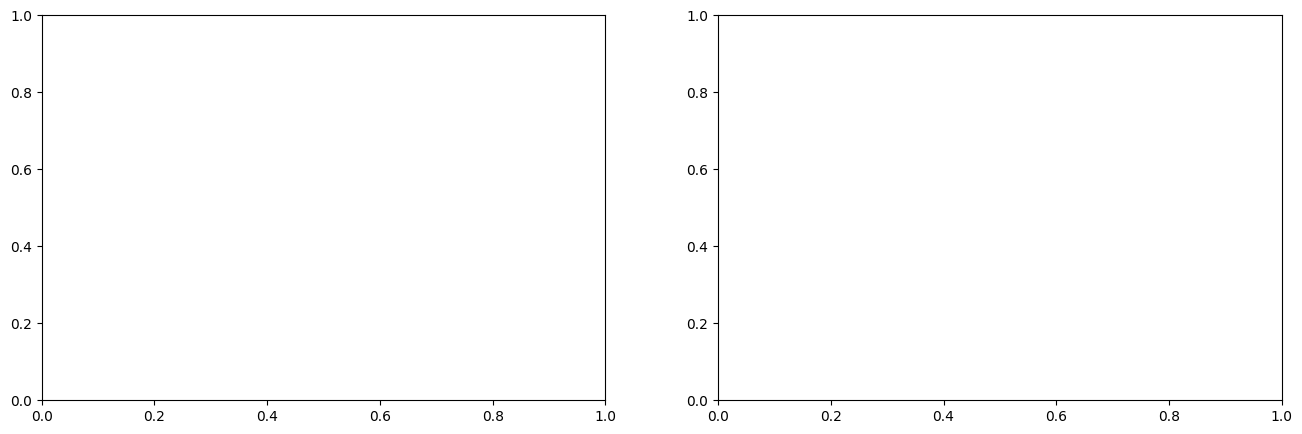

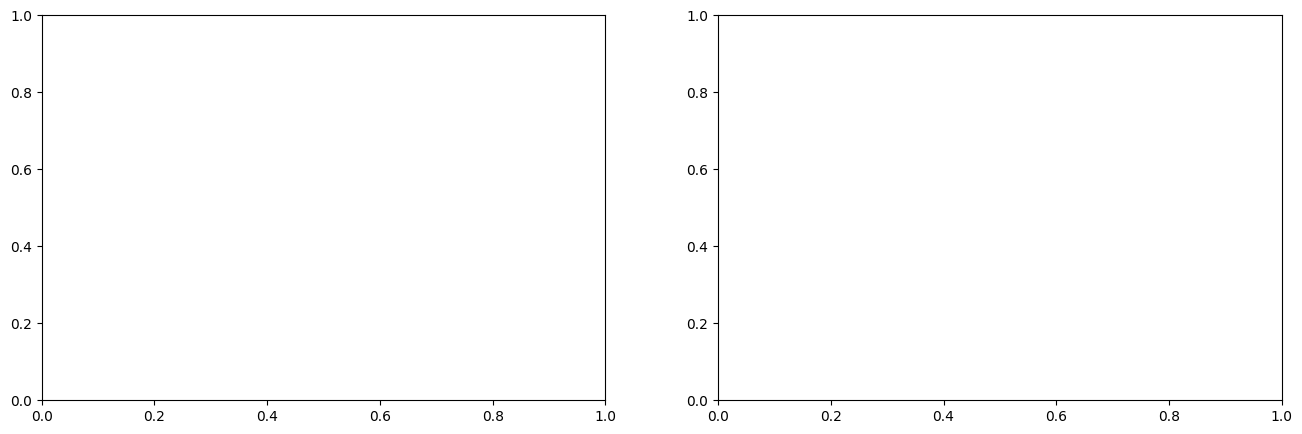

In [25]:
import optuna

def objective_cnn(trial):
    # define the hyper-parameters
    lr=trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay=trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)
    dropout=trial.suggest_float("dropout", 0.2, 0.7)
    opt_name=trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    hidden_dim=trial.suggest_int("hidden_size", 16, 64)
    
    # define models' parameteres
    in_ch=df_train.shape[1]
    in_ch, out_ch, device, dropout, kernel=define_parameters(in_ch, hidden_dim, dropout, kernel=3)
    # alternating or tunning the kernel requires adjustments to padding which is not suitable in this case
    model=construct_model(in_ch, out_ch, kernel, device, dropout, "CNN")

    # define the optimizer
    optimizer=optim.AdamW(
        model.parameters(),lr=lr,
        weight_decay=weight_decay) if opt_name == "Adam" else optim.SGD(
        model.parameters(),lr=lr,
        weight_decay=weight_decay
    )
    # specify the number of epochs
    # early stopping is applied
    num_epochs=30
    acc=train(model, num_epochs, batch_size=500, lr=0, weight_decay=0, tune=True, opt=optimizer, trial=trial)

    return acc

study=optuna.create_study(direction="minimize")
study.optimize(objective_cnn, n_trials=3)
print_tun_stat(study)

### Redo the training for the best model with the tuned hyper-parameters

In [50]:
# choosing the optimal hyper-parameters
params=study.best_params
in_ch=df_train.shape[1]
in_ch, out_ch, device, dropout, kernel=define_parameters(df_train.shape[1], params['hidden_size'], params['dropout'], kernel=3)
model=construct_model(in_ch, out_ch, kernel, device, dropout, "CNN")
# model=construct_model(in_ch, out_ch, kernel, device, dropout, "MLP")

Epoch: 1, Train Loss is: 0.58, Train Accuracy is: 0.68, Validation Loss:0.45, validation accuracy is: 0.79
Epoch: 2, Train Loss is: 0.46, Train Accuracy is: 0.79, Validation Loss:0.46, validation accuracy is: 0.78
Epoch: 3, Train Loss is: 0.35, Train Accuracy is: 0.85, Validation Loss:0.29, validation accuracy is: 0.88
Epoch: 4, Train Loss is: 0.33, Train Accuracy is: 0.86, Validation Loss:0.27, validation accuracy is: 0.89
Epoch: 5, Train Loss is: 0.30, Train Accuracy is: 0.88, Validation Loss:0.23, validation accuracy is: 0.91
Epoch: 6, Train Loss is: 0.29, Train Accuracy is: 0.88, Validation Loss:0.24, validation accuracy is: 0.90
Epoch: 7, Train Loss is: 0.24, Train Accuracy is: 0.91, Validation Loss:0.23, validation accuracy is: 0.91
Epoch: 8, Train Loss is: 0.22, Train Accuracy is: 0.91, Validation Loss:0.20, validation accuracy is: 0.92
Epoch: 9, Train Loss is: 0.19, Train Accuracy is: 0.93, Validation Loss:0.17, validation accuracy is: 0.93
Epoch: 10, Train Loss is: 0.19, Train

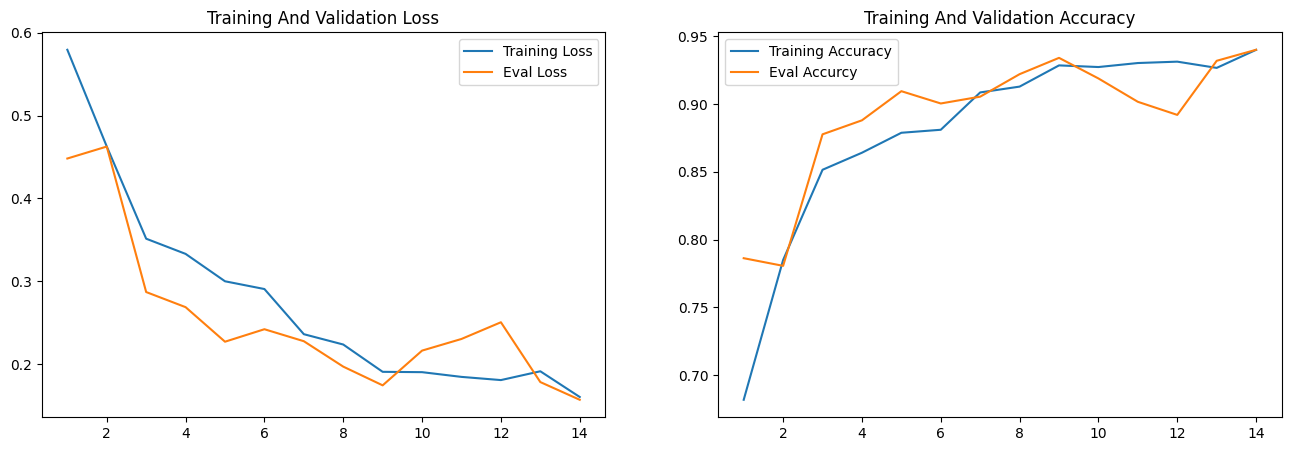

In [51]:
#TODO: select the optimal hyper-parameters
# build the model
# call the train function and train the model
train(model=model, num_epoch=30,batch_size=1000, lr=params['lr'], weight_decay=params['weight_decay'])
# save the model
torch.save(model, "model.pt")

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
def confusion_statistics(y_test, y_predict, labels, class_names):
    cm = confusion_matrix(y_test, y_predict, labels=labels)
    report=classification_report(y_test, y_predict, target_names=class_names)
    vis= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(20, 8))
    print(report)
    vis.plot(ax=ax)
    plt.show()

In [95]:
# Inference
def infer(image_loader, class_loader, model, device):
    eval_loss, correct, total=0,0,0
    criterion=nn.CrossEntropyLoss()
    model.eval()
    outputs=[]
    labels=[]
    with torch.no_grad():
        for images, label in zip(image_loader, class_loader):
            images, label= images.to(device, non_blocking=True), label.to(device, non_blocking=True)
            label=label.squeeze()
            output=model(images)
            loss=criterion(output, label)
            eval_loss+=loss.item() * label.size(0)
            preds=output.argmax(dim=1)
            correct+=(preds==label).sum().item()
            total+=label.size(0)
            outputs.append(output.argmax(1).squeeze())
            labels.append(label)
    return eval_loss/total, correct/total, labels, outputs

In [96]:
# write the testing function
def inference(batch_size, device):
    model=torch.load("model.pt", weights_only=False)
    test_images, test_labels=test_obj.prepare()
    test_loader, test_class=data_loading(test_images, batch_size), data_loading(test_labels, batch_size)
    loss, accuracy, y_test, outputs=infer(test_loader, test_class, model, device)
    labels=[0,1]
    class_names=["FAKE", "REAL"]
    print(f"Inference Accuracy: {accuracy}")
    print(f"Infernce Loss:{loss}")
    outputs=torch.concat(outputs)
    y_test=torch.concat(y_test)
    outputs=outputs.cpu().numpy()
    y_test=y_test.cpu().numpy()
    confusion_statistics(y_test, outputs,labels, class_names)

Inference Accuracy: 0.9376
Infernce Loss:0.16623570583760738
              precision    recall  f1-score   support

        FAKE       0.96      0.91      0.94     10000
        REAL       0.91      0.97      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



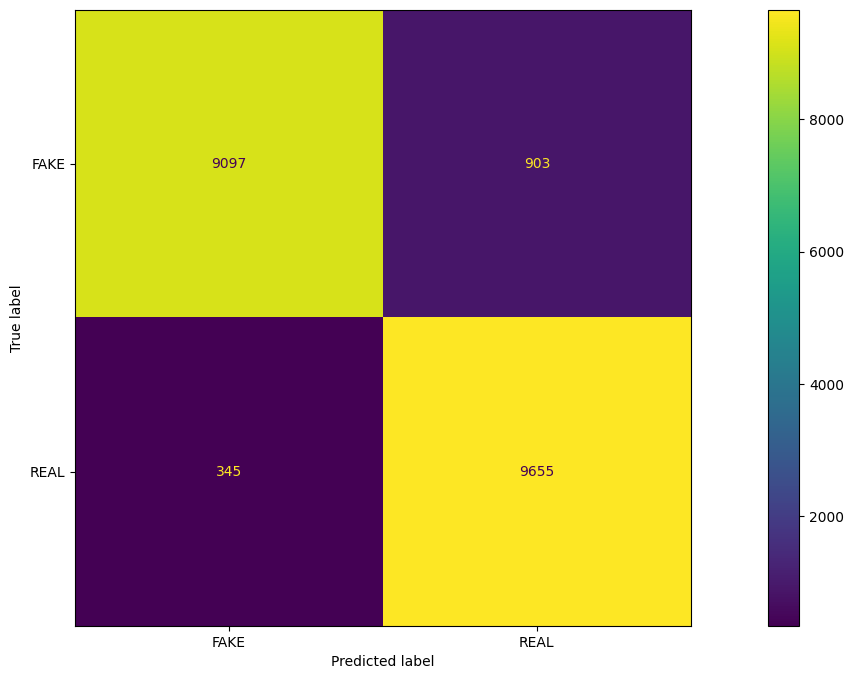

In [97]:
inference(5000, device)